<a href="https://colab.research.google.com/github/sambencoding/Data-Science-Assignments/blob/main/SamuBenjU6proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install bambi
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import matplotlib.pyplot as plt
import bambi as bmb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.2/109.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 2.6 MB/s eta 0:00:00


#Green House Gas by Country and Population

Greenhouse gases are gases in the Earth's atmosphere that trap heat, allowing sunlight to pass through but preventing the heat from escaping, essentially acting like a blanket around the planet.
In this project, I chose to use Greenhouse gas stastics per each country and compare how drastically different each country is.

In [2]:
url_greenhouse = 'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/greenhousegas_pop_10nations.csv'
ghg = pd.read_csv(url_greenhouse, dtype={'country':'category'})

In [3]:
ghg

,country,code,year,grnGasEm100K,pop10M
0,Brazil,BRA,1970,12.6098,9.5982
1,Canada,CAN,1970,4.9497,2.1324
2,China,CHN,1970,18.7397,81.8315
3,Germany,DEU,1970,12.8657,7.8169
4,France,FRA,1970,6.1450,5.2035
...,...,...,...,...,...
425,United Kingdom,GBR,2012,5.8578,6.3700
426,India,IND,2012,30.0289,126.3590
427,Japan,JPN,2012,14.7886,12.7561
428,Mexico,MEX,2012,6.6342,12.2071


<Axes: xlabel='year', ylabel='grnGasEm100K'>

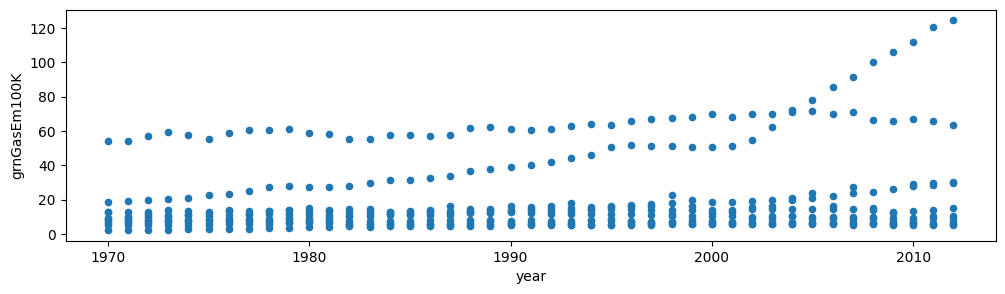

In [4]:
ghg.plot(x="year", y="grnGasEm100K", figsize=(12, 3), kind="scatter")

Output()

Output()

/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


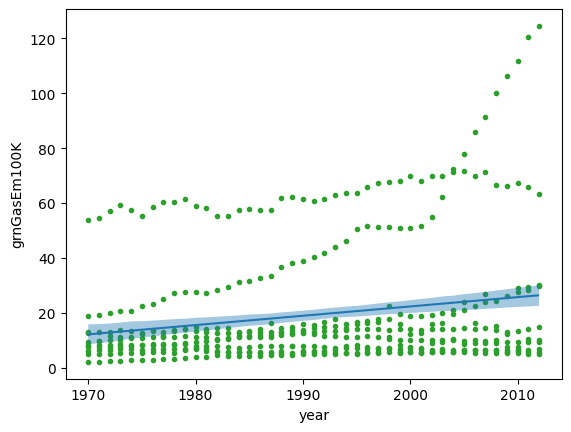

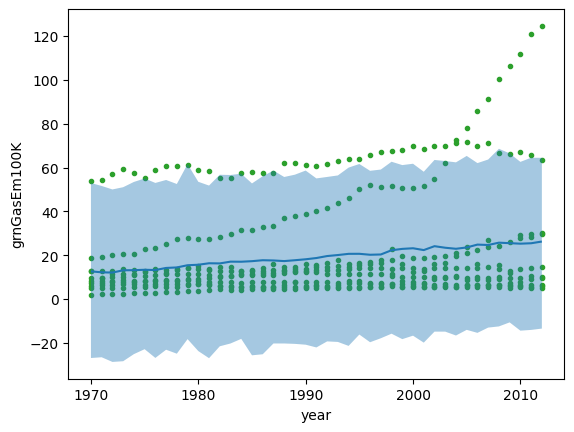

In [5]:
model_1 = bmb.Model("grnGasEm100K ~ year", data=ghg)
idata_model_1 = model_1.fit(idata_kwargs={'log_likelihood': True})
model_1
bmb.interpret.plot_predictions(model_1, idata_model_1, "year")
plt.plot(ghg.year, ghg.grnGasEm100K, "C2.", zorder=-3)
bmb.interpret.plot_predictions(model_1, idata_model_1, "year", pps = True)
plt.plot(ghg.year, ghg.grnGasEm100K, "C2.", zorder=-3)

Output()

Output()

/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


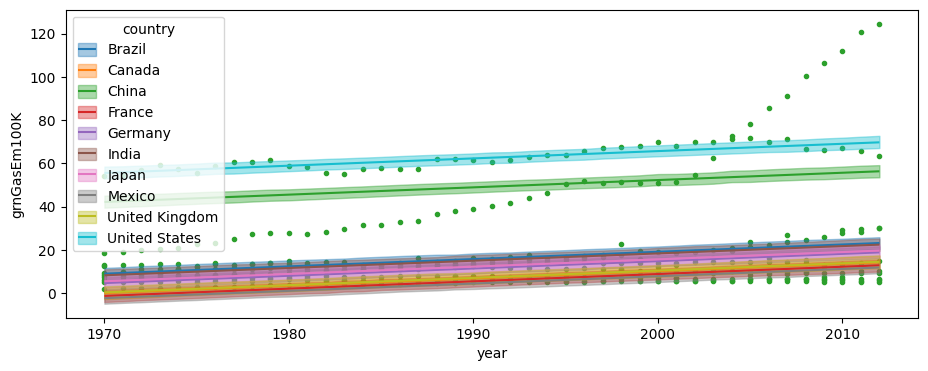

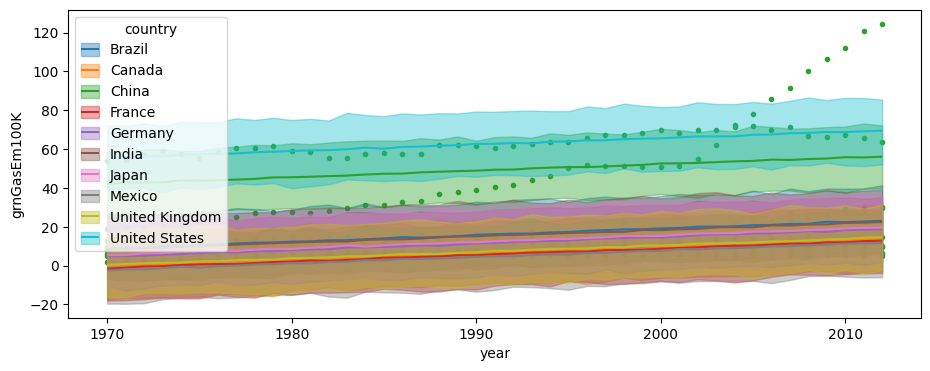

In [13]:
model_country = bmb.Model("grnGasEm100K ~ year + country", data=ghg)
idata_model_country = model_country.fit(idata_kwargs={'log_likelihood': True})
model_country
bmb.interpret.plot_predictions(model_country, idata_model_country, ["year", "country"], fig_kwargs={"figsize":(11, 4)})
plt.plot(ghg.year, ghg.grnGasEm100K, "C2.", zorder=-3)
bmb.interpret.plot_predictions(model_country, idata_model_country, ["year", "country"], fig_kwargs={"figsize":(11, 4)}, pps = True)
plt.plot(ghg.year, ghg.grnGasEm100K, "C2.", zorder=-3)

Output()

Output()

/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


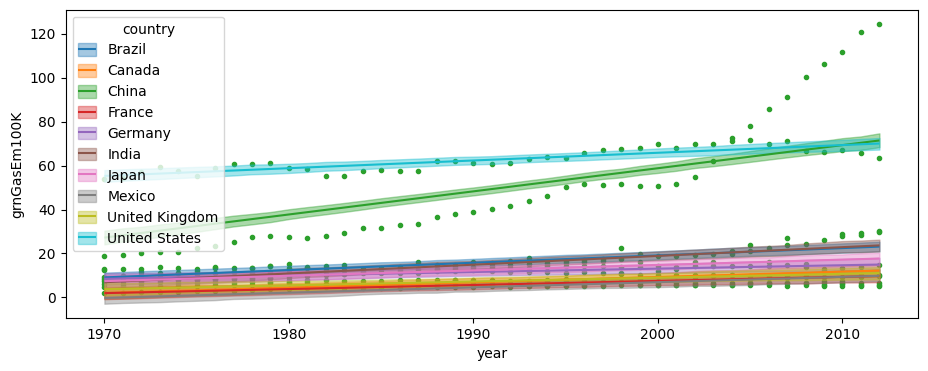

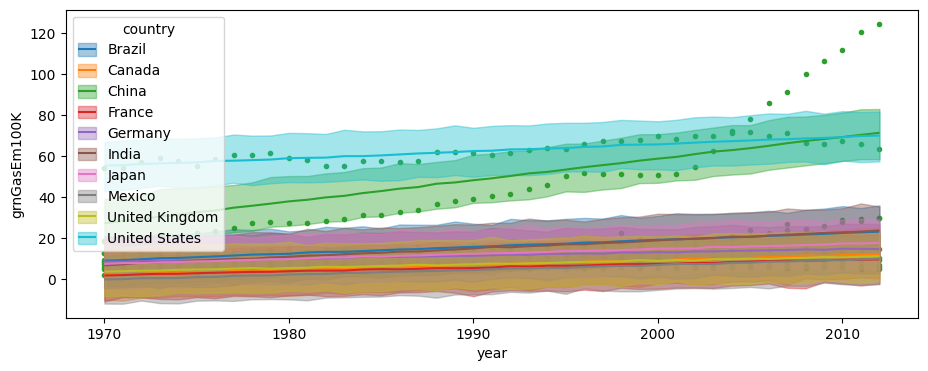

In [7]:
model_countryint = bmb.Model("grnGasEm100K ~ year + country + year:country", data=ghg)
idata_model_countryint = model_countryint.fit(idata_kwargs={'log_likelihood': True})
model_countryint
bmb.interpret.plot_predictions(model_countryint, idata_model_countryint, ["year", "country"], fig_kwargs={"figsize":(11, 4)})
plt.plot(ghg.year, ghg.grnGasEm100K, "C2.", zorder=-3)
bmb.interpret.plot_predictions(model_countryint, idata_model_countryint, ["year", "country"], fig_kwargs={"figsize":(11, 4)}, pps = True)
plt.plot(ghg.year, ghg.grnGasEm100K, "C2.", zorder=-3)

In [8]:
model_popcountryint = bmb.Model("grnGasEm100K ~ year + country + pop10M + year:country", data=ghg)
idata_model_popcountryint = model_popcountryint.fit(idata_kwargs={'log_likelihood': True})

Output()

Output()

/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arviz/rcparams.py:368: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


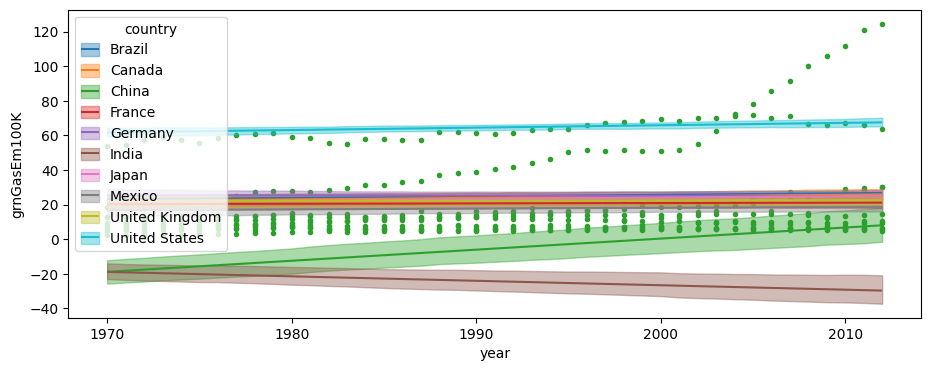

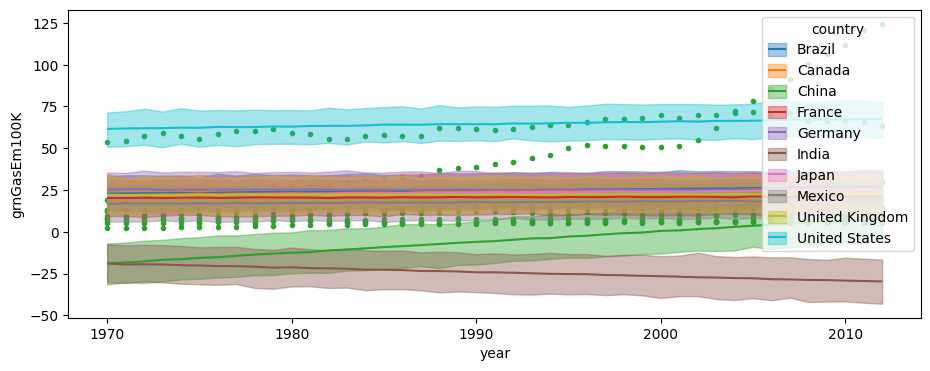

In [9]:
#posterior mean and posterior predictive
bmb.interpret.plot_predictions(model_popcountryint, idata_model_popcountryint, ["year", "country"], fig_kwargs={"figsize":(11, 4)})
plt.plot(ghg.year, ghg.grnGasEm100K, "C2.", zorder=-3)

bmb.interpret.plot_predictions(model_popcountryint, idata_model_popcountryint, ["year", "country"], fig_kwargs={"figsize":(11, 4)}, pps = True)
plt.plot(ghg.year, ghg.grnGasEm100K, "C2.", zorder=-3)


/usr/local/lib/python3.11/dist-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/arviz/stats/stats.py:795: UserWarning: Estimat

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

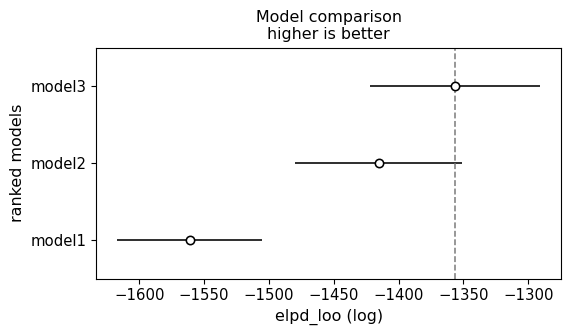

In [14]:
loo_1 = az.loo(idata_model_country)
loo_2 = az.loo(idata_model_countryint)
loo_3 = az.loo(idata_model_popcountryint)

cmp_df = az.compare( {"model1":idata_model_country, "model2":idata_model_countryint, "model3":idata_model_popcountryint} )
cmp_df
az.plot_compare(cmp_df)


#Conclusion
The results suggest distinct trends in grngas100K across countries. Some, like the United States and Brazil, show a steady increase, whereas others, such as China and India, display different trajectories with greater variation. The uncertainty intervals highlight the confidence in predictions, with wider bands indicating greater uncertainty. The model captures broad trends but may require further refinement to account for potential nonlinearities or external influencing factors.

Also Model 3 is the model that performs the best between the 3 models. Model 3 predicts the greenhouse gas emmisions of the ten countries given the best.

